In [76]:

import warnings
warnings.filterwarnings("ignore")

import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
)
from tensorflow.keras.callbacks import Callback

import akshare as ak

SEED = 42
TIME_STEPS = 30
TEST_SIZE = 100

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [77]:
def _retry_fetch(fetch_fn, retries=5, sleep_seconds=2, name="data"):
    """没爬成功重新爬 网络波动时自动重试"""
    last_error = None
    for i in range(retries):
        try:
            return fetch_fn()
        except Exception as e:
            last_error = e
            print(f"[{name}] attempt {i + 1}/{retries} failed: {e}")
            if i < retries - 1:
                time.sleep(sleep_seconds)
    raise RuntimeError(f"[{name}] 获取失败，已重试 {retries} 次") from last_error


HS300_CACHE = "hs300_cache.csv"
FU0_CACHE = "fu0_cache.csv"


def fetch_hs300_close(base_dates):
    """获取沪深300历史收盘价"""
    if os.path.exists(HS300_CACHE):
        cache_df = pd.read_csv(HS300_CACHE)
        if {"date", "hs300_close"}.issubset(cache_df.columns):
            cache_df["date"] = pd.to_datetime(cache_df["date"])
            cache_df["hs300_close"] = pd.to_numeric(cache_df["hs300_close"], errors="coerce")
            cache_df = cache_df.sort_values("date").drop_duplicates("date").reset_index(drop=True)
            print(f"[HS300] 已读取本地缓存: {HS300_CACHE}")
            return cache_df

    def _fetch_primary():
        return ak.index_zh_a_hist(
            symbol="000300",
            period="daily",
            start_date="20000101",
            end_date="20991231",
        )

    def _fetch_backup():
        return ak.stock_zh_index_daily_em(symbol="sh000300")

    hs300_df = None
    try:
        hs300_df = _retry_fetch(_fetch_primary, retries=5, sleep_seconds=2, name="HS300-primary")
    except Exception:
        hs300_df = _retry_fetch(_fetch_backup, retries=5, sleep_seconds=2, name="HS300-backup")

    column_map = {}
    if "日期" in hs300_df.columns:
        column_map["日期"] = "date"
    elif "date" in hs300_df.columns:
        column_map["date"] = "date"
    else:
        for col in hs300_df.columns:
            if "日" in str(col) or "date" in str(col).lower():
                column_map[col] = "date"
                break

    if "收盘" in hs300_df.columns:
        column_map["收盘"] = "hs300_close"
    elif "close" in hs300_df.columns:
        column_map["close"] = "hs300_close"
    else:
        for col in hs300_df.columns:
            if "close" in str(col).lower() or "收盘" in str(col):
                column_map[col] = "hs300_close"
                break

    hs300_df = hs300_df.rename(columns=column_map)
    hs300_df = hs300_df[["date", "hs300_close"]].copy()
    hs300_df["date"] = pd.to_datetime(hs300_df["date"])
    hs300_df["hs300_close"] = pd.to_numeric(hs300_df["hs300_close"], errors="coerce")
    hs300_df = hs300_df.sort_values("date").drop_duplicates("date").reset_index(drop=True)
    hs300_df.to_csv(HS300_CACHE, index=False)
    print(f"[HS300] 已保存本地缓存: {HS300_CACHE}")
    return hs300_df


def fetch_fuel_oil_close(base_dates):
    """燃料油主连收盘价"""
    if os.path.exists(FU0_CACHE):
        cache_df = pd.read_csv(FU0_CACHE)
        if {"date", "fu_close"}.issubset(cache_df.columns):
            cache_df["date"] = pd.to_datetime(cache_df["date"])
            cache_df["fu_close"] = pd.to_numeric(cache_df["fu_close"], errors="coerce")
            cache_df = cache_df.sort_values("date").drop_duplicates("date").reset_index(drop=True)
            print(f"[FU0] 已读取本地缓存: {FU0_CACHE}")
            return cache_df

    def _fetch():
        return ak.futures_zh_daily_sina(symbol="FU0")

    try:
        fu_df = _retry_fetch(_fetch, retries=5, sleep_seconds=2, name="FU0")
    except Exception as e:
        print(f"[FU0] 使用兜底占位特征，原因: {e}")
        return pd.DataFrame({"date": pd.to_datetime(base_dates), "fu_close": np.nan})

    column_map = {}
    if "date" in fu_df.columns:
        column_map["date"] = "date"
    elif "日期" in fu_df.columns:
        column_map["日期"] = "date"

    if "close" in fu_df.columns:
        column_map["close"] = "fu_close"
    elif "收盘价" in fu_df.columns:
        column_map["收盘价"] = "fu_close"
    elif "收盘" in fu_df.columns:
        column_map["收盘"] = "fu_close"

    fu_df = fu_df.rename(columns=column_map)
    fu_df = fu_df[["date", "fu_close"]].copy()
    fu_df["date"] = pd.to_datetime(fu_df["date"])
    fu_df["fu_close"] = pd.to_numeric(fu_df["fu_close"], errors="coerce")
    fu_df = fu_df.sort_values("date").drop_duplicates("date").reset_index(drop=True)
    fu_df.to_csv(FU0_CACHE, index=False)
    print(f"[FU0] 已保存本地缓存: {FU0_CACHE}")
    return fu_df


def create_sequences(features, target, time_steps=30):
    xs, ys = [], []
    for i in range(len(features) - time_steps):
        xs.append(features[i : i + time_steps])
        ys.append(target[i + time_steps])
    return np.array(xs), np.array(ys)


# 读取数据，并按日期升序排序
df = pd.read_csv("CEA.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date", ascending=True).reset_index(drop=True)

# 基础字段转数值
for col in ["close"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 时间特征与履约期特征
df["Month"] = df["date"].dt.month
df["is_compliance"] = df["Month"].isin([6, 7, 8]).astype(int)

# 滞后特征
df["lag_1"] = df["close"].shift(1)
df["lag_2"] = df["close"].shift(2)

# 合并沪深300收盘价
try:
    hs300 = fetch_hs300_close(df["date"])
    df = df.merge(hs300, on="date", how="left")
except Exception as e:
    print(f"[HS300] 使用兜底占位特征，原因: {e}")
    df["hs300_close"] = np.nan

df["hs300_close"] = df["hs300_close"].ffill().bfill()
if df["hs300_close"].isna().all():
    df["hs300_close"] = df["close"]

# 合并燃料油主连(FU0 / 同花顺 fu9999)收盘价
fu_hist = fetch_fuel_oil_close(df["date"])
df = df.merge(fu_hist, on="date", how="left")
df["fu_close"] = df["fu_close"].ffill().bfill()
if df["fu_close"].isna().all():
    df["fu_close"] = df["close"]

# 删除缺失值
df = df.dropna().reset_index(drop=True)

# 构建特征和目标
# feature_cols = [
#     "close",
#     "Month", "is_compliance",
#     "lag_1", "lag_2", "hs300_close", "fu_close"
# ]
feature_cols = [
    "close", "Month",
    "lag_1", "lag_2", "hs300_close", "fu_close"
]
target_col = "close"

X_raw = df[feature_cols].values
y_raw = df[[target_col]].values

# 滑动窗口：30天预测第31天
X_seq_raw, y_seq_raw = create_sequences(X_raw, y_raw, time_steps=TIME_STEPS)
if len(X_seq_raw) <= TEST_SIZE:
    raise ValueError(f"样本不足，窗口后样本数={len(X_seq_raw)}，无法划分最后{TEST_SIZE}个样本做测试")

# 时间顺序划分：最后100个样本为测试集
X_train_raw, X_test_raw = X_seq_raw[:-TEST_SIZE], X_seq_raw[-TEST_SIZE:]
y_train_raw, y_test_raw = y_seq_raw[:-TEST_SIZE], y_seq_raw[-TEST_SIZE:]

# X与y分别独立归一化
x_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))

X_train_2d = X_train_raw.reshape(-1, X_train_raw.shape[-1])
X_test_2d = X_test_raw.reshape(-1, X_test_raw.shape[-1])

x_scaler.fit(X_train_2d)
X_train_scaled = x_scaler.transform(X_train_2d).reshape(X_train_raw.shape)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test_raw.shape)

y_scaler.fit(y_train_raw)
y_train_scaled = y_scaler.transform(y_train_raw)
y_test_scaled = y_scaler.transform(y_test_raw)

print("Train shape:", X_train_scaled.shape, y_train_scaled.shape)
print("Test shape:", X_test_scaled.shape, y_test_scaled.shape)


[HS300] 已读取本地缓存: hs300_cache.csv
[FU0] 已读取本地缓存: fu0_cache.csv
Train shape: (1022, 30, 6) (1022, 1)
Test shape: (100, 30, 6) (100, 1)


In [78]:
def build_model(time_steps, num_features):
    inputs = Input(shape=(time_steps, num_features))
    x = LSTM(64, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False)(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model


class TestSetBestSaver(Callback):
    def __init__(self, x_test, y_test_scaled, y_scaler, save_path="best_lstm_test.weights.h5"):
        super().__init__()
        self.x_test = x_test
        self.y_test_scaled = y_test_scaled
        self.y_scaler = y_scaler
        self.save_path = save_path
        self.best_rmse = np.inf
        self.best_epoch = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        y_pred_scaled_epoch = self.model.predict(self.x_test, verbose=0)
        y_pred_epoch = self.y_scaler.inverse_transform(y_pred_scaled_epoch)
        y_true_epoch = self.y_scaler.inverse_transform(self.y_test_scaled)
        rmse_epoch = np.sqrt(mean_squared_error(y_true_epoch, y_pred_epoch))

        if rmse_epoch < self.best_rmse:
            self.best_rmse = rmse_epoch
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights()
            self.model.save_weights(self.save_path)
            print(f"\nEpoch {epoch + 1}: test RMSE improved to {rmse_epoch:.6f}, best weights saved.")


test_best_saver = TestSetBestSaver(X_test_scaled, y_test_scaled, y_scaler)

model = build_model(time_steps=TIME_STEPS, num_features=X_train_scaled.shape[-1])
model.summary()

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=150,
    batch_size=32,
    callbacks=[test_best_saver],
    verbose=1,
)

# 回载测试集最优epoch权重
if test_best_saver.best_weights is not None:
    model.set_weights(test_best_saver.best_weights)
    print(f"Using best test epoch: {test_best_saver.best_epoch}, best test RMSE: {test_best_saver.best_rmse:.6f}")

# 测试集预测并反归一化
y_pred_scaled = model.predict(X_test_scaled, verbose=0)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_scaled)

# 评估指标
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"MAPE: {mape:.4f}%")
print(f"R2: {r2:.6f}")


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 30, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1442
Epoch 1: test RMSE improved to 6.591671, best weights saved.
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1290
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0107
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0087
Epoch 4/150
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0090
Epoch 4: test RMSE improved to 4.988743, best weights saved.
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0088
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0074
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068
Epoch 8/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0074
Epoch 9/150
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0062
Epoch 9: test RMSE improved to 4.721810, best weights saved.
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0062
Epoch 10/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 

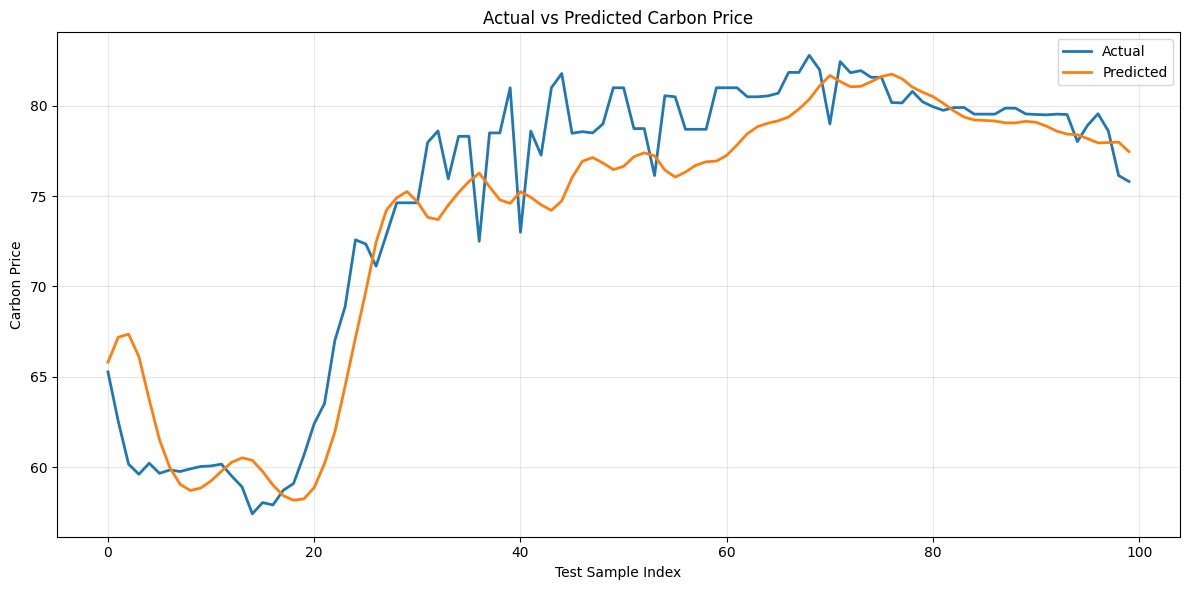

In [79]:
plt.figure(figsize=(12, 6))
plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted Carbon Price")
plt.xlabel("Test Sample Index")
plt.ylabel("Carbon Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [80]:
save_path = "test_predictions.csv"

result_df = pd.DataFrame({
    "actual_close": y_true.flatten(),
    "predicted_close": y_pred.flatten(),
    "error": (y_pred - y_true).flatten(),
    "abs_error": np.abs(y_pred - y_true).flatten(),
})

result_df.to_csv(save_path, index=False)
print(f"预测结果已保存至: {save_path}")
print(result_df.to_string(index=False))


预测结果已保存至: test_predictions.csv
 actual_close  predicted_close     error  abs_error
        65.27        65.806229  0.536229   0.536229
        62.53        67.188583  4.658583   4.658583
        60.16        67.358505  7.198505   7.198505
        59.60        66.115555  6.515555   6.515555
        60.21        63.738091  3.528091   3.528091
        59.65        61.508972  1.858972   1.858972
        59.84        59.970196  0.130196   0.130196
        59.75        59.041592 -0.708408   0.708408
        59.90        58.699371 -1.200629   1.200629
        60.03        58.837608 -1.192392   1.192392
        60.06        59.233837 -0.826163   0.826163
        60.16        59.764530 -0.395470   0.395470
        59.50        60.263824  0.763824   0.763824
        58.90        60.508072  1.608072   1.608072
        57.41        60.374348  2.964348   2.964348
        58.03        59.748093  1.718093   1.718093
        57.90        58.998547  1.098547   1.098547
        58.71        58.413219 -0